In [2]:
%cd ..

/gpfs/data/schambralab/quantitativeRehabilitation/__lab_member_homes/victor/cvfm4rehab


In [22]:
import os
from data.utils_strokerehab import strokerehab_load_dataset, LabelUtils, DataPaths

ds = strokerehab_load_dataset(patients='C00015', reps='first')
len(ds['test'])
print(ds['test']['path_l'])

['C00015/C00015_RTT left side1_1.csv', 'C00015/C00015_RTT right side1_1.csv', 'C00015/C00015_brushing1_1.csv', 'C00015/C00015_combing1_1.csv', 'C00015/C00015_deodrant1_1.csv', 'C00015/C00015_drinking1_1.csv', 'C00015/C00015_face wash1_1.csv', 'C00015/C00015_feeding1_1.csv', 'C00015/C00015_glasses1_1.csv', 'C00015/C00015_shelf left side1_1.csv', 'C00015/C00015_shelf right side1_1.csv']


In [28]:
# Convert prims and times into three binary sequences
# 1. motion: reach, transport, reposition
# 2. contact: stabilize, transport
# reposition = no contact in "immediate" future
# contact = contact in "immediate" future

def get_prims_motion_contact(path_l):
    full_path = os.path.join(DataPaths.RAW_LABEL_DIR, path_l)
    prims, times = LabelUtils.convert_labels_to_prims_times(full_path)

    motion, contact = [], []

    for prim in prims:
        motion.append(prim in ['reach', 'transport', 'reposition'])
        contact.append(prim in ['stabilize', 'transport'])
    return prims, motion, contact, times

prims_motion_contact = [get_prims_motion_contact(path_l) for path_l in ds['test']['path_l']]

In [33]:
from lmms_eval.tasks.strokerehab.utils_primitives import _get_primitives_score


def motion_contact_flags_to_primitives(motion_flags, contact_flags, times, future_window=5.0):
    primitives = []
    start_times = times[:-1]  # length n
    n = len(start_times)

    for i in range(n):
        t0 = start_times[i]
        m = motion_flags[i]
        c = contact_flags[i]

        if m and not c:
            # scan ahead up to future_window
            reach = False
            j = i + 1
            while j < n and (start_times[j] - t0) <= future_window:
                if contact_flags[j]:
                    reach = True
                    break
                j += 1
            prim = "reach" if reach else "reposition"

        elif m and c:
            prim = "transport"

        elif not m and c:
            prim = "stabilize"

        else:  # not m and not c
            prim = "idle"

        primitives.append(prim)
    
    return primitives

import numpy as np
def evaluate_window(future_window=5.0):
    scores = []

    for gt_prims, motion_flags, contact_flags, times in prims_motion_contact:
        pred_prims = motion_contact_flags_to_primitives(
            motion_flags, contact_flags, times, future_window=future_window
        )
        score_dict = _get_primitives_score(pred_prims, gt_prims)
        edit_score = score_dict['edit_score']
        # action_error_rate = -score_dict['action_error_rate']
        # mae_avg = -score_dict['mae_avg']
        scores.append(edit_score)
    return np.mean(scores)

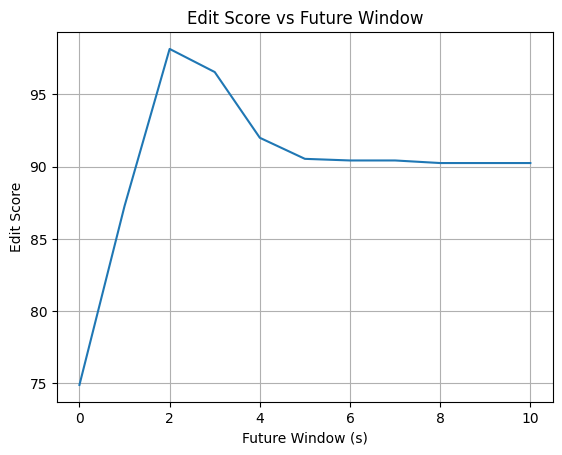

In [35]:
future_window = np.linspace(0.0, 10.0, 11)
scores = [evaluate_window(future_window=f) for f in future_window]
import matplotlib.pyplot as plt
plt.plot(future_window, scores)
plt.xlabel('Future Window (s)')
plt.ylabel('Edit Score')
plt.title('Edit Score vs Future Window')
plt.grid()
plt.show()

In [36]:
# We should use 2.0 seconds as the future window for the primitives evaluation.